In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, pt_config, data, adam_hash, hash_configs
import json


In [2]:
base_dir = Path.cwd()
print(base_dir)
cutout = 10000

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
if data["dn"].lower() == "dayu19a":
    true_sample = np.load(base_path / "inputdata_260219A" / "true_sample.npy")
    bin_range = (1676, 1727)
    data_color = "red"
    data_name = r"$A_1$"
    ylim_max = 0.4
elif data["dn"].lower() == "dayu19b":
    true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
    bin_range = (1660, 1720)
    data_color = "orange"
    data_name = r"$A_2$"
    ylim_max = 0.15
if data["dn"].lower() == "dayu19c":
    true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
    bin_range = (1680, 1720)
    data_color = "yellow"
    data_name = r"$A_3$"
    ylim_max = 0.25
print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal
dayu19a
[ 4.57902257  8.36135651  5.11422104  8.94774521  3.77633915  2.62301897
  7.51392662  3.01083465  1.66440672  2.49766516  6.65021419  4.26488131
  2.82178752 13.72110374  5.00658969  4.22356615  9.98407875  5.05228054
 14.98356018  6.87770972  5.76046943  3.36974485  2.4027257   4.29853801
 13.58724645  4.44886226  5.27841171  8.50856018  3.61890868  1.97566217
  7.51449837  2.73906955 11.11440187  3.84391012  4.29268555  6.33982014
 12.47922743  5.8959843   6.12628828  1.71823439 23.98511197  1.41829163
 14.66210819 15.02047988  4.88741433 21.95400098 27.77322018  3.71905004
  3.71382915 42.30520838]
[1983.         1973.84195486 1957.11924185 1946.89079978 1928.99530935
 1921.44263104 1916.1965931  1901.16873986 1895.14707057 1891.81825712
 1886.8229268  1873.52249843 1864.99273582 1859.34916077 1831.90695329
 1821.8937739  1813.44664161 1793.47848412 1783.37392303 1753.40680268
 1739.65138

In [3]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 10000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# starting_points = np.load(adam_dir / "adam_samples.npy")
# energies = np.load(adam_dir / "adam_energies.npy")

# indices = np.argsort(energies)
# sp = starting_points[indices][:pt_config["nt"]]
sp_dir = base_dir / f"output/{data['dn']}/sd_{pt_config["hmcc"]["sd"]}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
print(output_dir)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal\output\dayu19A\sd_10\fda6b870d8


In [5]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

In [6]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [7]:

# cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
# zeros = np.zeros((*sp.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(sp)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{sp_dir}/sp_age_depth.jpg")
# plt.show()

In [8]:

# cumulative_sums = np.cumsum(starting_points, axis=1) * data["dc"]
# zeros = np.zeros((*starting_points.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# print(np.shape(age_offsets))

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(starting_points)
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[j, :],
#         color='green',
#         alpha=1,
#         linewidth=1,
#     )
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# # plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# # plt.savefig(f"{adam_dir}/all_sp_age_depth.jpg")
# plt.show()

In [9]:
# import matplotlib as mpl

# num_starts = 5
# temp_indices = np.load(output_dir / "temp_indices.npy")
# norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
# cmap = plt.cm.viridis
# # temp_indices = (temp_indices == 19).argmax(axis=0)
# print(temp_indices)
# print(np.shape(temp_indices))
# plt.figure(figsize=(6, 4))
# xmin = 10000
# xmax = 90000
# # for i in range(len(temp_indices)):
# plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
# for i in range(0, num_starts):
#     temp_indices_i = (temp_indices == i).argmax(axis=0)
#     plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
# print(temp_indices)
# plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
# plt.ylabel("s")
# plt.xlabel("q")
# plt.legend(loc = "upper right")
# plt.savefig(f"{output_dir}/index_evolution.jpg")
# plt.show()


In [10]:
# backwards = False
# round_trip = 0
# num_temps = len(temp_indices)
# num_samples = len(temp_indices[0, cutout:])
# for chain in range(num_temps):
#     for col in range(num_samples):
#         if temp_indices[0, col] == chain and backwards:
#             round_trip+=1
#             backwards = False
#         if temp_indices[-1, col] == chain:
#             backwards = True
# print(round_trip / (num_samples * num_temps))


In [11]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [12]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(77.79063887394138), np.float64(78.94359523143737), np.float64(81.65619803957986), np.float64(84.41879716082518), np.float64(84.9109818310889), np.float64(88.1037131324333), np.float64(89.54042675220933), np.float64(94.15702178885962), np.float64(97.57281209986243), np.float64(101.30284729971831), np.float64(105.1902497718991), np.float64(112.5259453115548), np.float64(119.5014677964432), np.float64(123.42956304846228), np.float64(135.05411128644076), np.float64(142.75797085188876), np.float64(154.26943213488127), np.float64(168.57190097556753), np.float64(183.8070889953173), np.float64(202.18481618049213)]


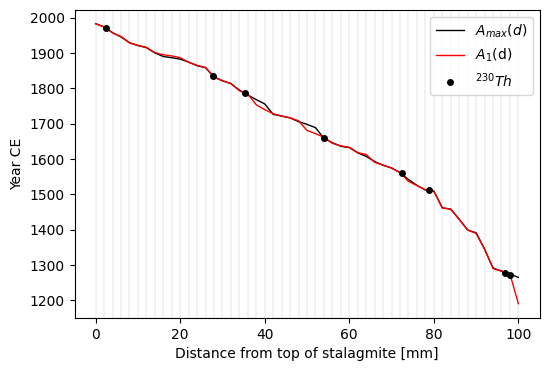

In [13]:
chain = -1
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = data_color, linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()

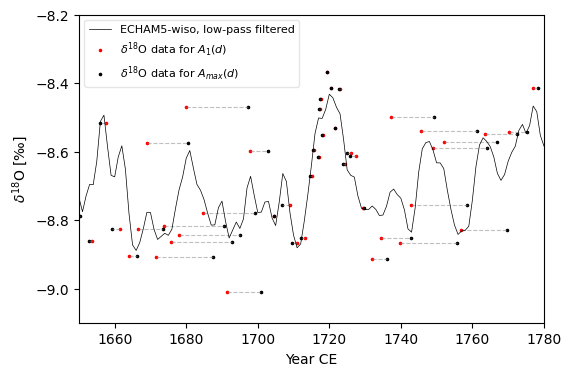

In [55]:
fig, ax = plt.subplots(figsize=(6, 4))
# 1. Define your two sets of X coordinates
x_data = data["d18ota"]
x_model = np.interp(
    data["d18od"], 
    data["cs"], 
    data["th"] - data["dc"] * np.hstack(([chain], np.cumsum(min_energy_samples[chain])))
)
y_vals = data["d18o"] # The Y values are the same for both, right?
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.scatter(
    x_data, 
    y_vals, 
    color=data_color, 
    marker = ".", 
    s = 10,
    label=r"$\delta^{18}$O data for $A_1(d)$"
)

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"Data regenerated from $A_{close}(d)$"
# )

ax.scatter(
    x_model, 
    y_vals, 
    # yerr=data["d18os"],       # The error values (can be a constant or array)
    color="black", 
    marker=".", 
    s=10,                # Makes the stars smaller (default is 6)
    # linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    # elinewidth=0.5,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)

# 2. Loop through and draw a line between each corresponding pair
for i in range(len(y_vals)):
    ax.plot(
        [x_data[i], x_model[i]], # X-start to X-end
        [y_vals[i], y_vals[i]], # Y-start to Y-end (stays on same horizontal line)
        color="grey", 
        linestyle="--", 
        linewidth=0.8,
        alpha=0.5,           # Makes lines subtle so they don't crowd the plot
        zorder=1             # Puts the lines behind the scatter stars
    )
# ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
plt.xlim((1650, 1780))
plt.ylim((-9.1, -8.2))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend(loc = "upper left", framealpha=0.5, prop={'size': 8})
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [15]:
import arviz as az
# for i in range(len(samples[-1,0,:])):    
#     print(f"ess x[{i}]: {az.ess(samples[-1, :, i], method="bulk")}")

ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[455390.21813297 416906.20955406 475170.98152526 306854.79025681
 240880.82505319 215159.89775724 514322.16425789 124895.78497083
  71888.67278358  46787.72719287 173298.56722102 289454.9832104
  68876.30292813  36494.75328424  81339.57912459 170074.53889006
 378066.79257766  66449.93698733  14507.97157203 344918.02451451
  14541.62376698 102861.40416427 339213.20426951 144068.07039309
  40794.52500909 171382.14127866  43989.74571961 172125.17120082
 295306.79463571 342099.7258698  596032.02081868 375392.20588284
 396486.83596731 554614.78006539 842133.02295208 350093.61043517
 190029.08471249 209771.44696594 204484.45407809 502851.65946383
 599737.30022543 672600.62135359 443812.74237232 449022.57608714
 754066.34431305 654454.56201299 478224.6252823  299159.2571492
 309337.40897958 169064.92545408]
14507.971572032397


In [16]:
print(output_dir)
print(min_ess)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal\output\dayu19A\sd_10\fda6b870d8
14507.971572032397


In [17]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[0,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[-1, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# plt.show()

In [18]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[-1,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[0, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_highT_samples.jpg")
# plt.show()

In [19]:
short_samples = samples[-1, ::int(len(samples[-1, :, 0]) / min_ess), :]

In [20]:
# index = 25
# interesting_depth = index * data["dc"]
# CV_values = data["th"] - data["dc"] * np.sum(short_samples[:, :index], axis = 1)
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
# ax.set_xlabel("Year CE")
# ax.set_ylabel("Marginal Density")
# ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
# plt.legend()
# plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
# plt.show()

In [21]:
index = 25
interesting_depth = index * data["dc"]
dt = 1

0.0
0.0068686036128855
0.013737207225771
0.0206058108386565
0.027474414451542
0.0343430180644275
0.041211621677313
0.0480802252901985
0.054948828903084
0.0618174325159695
0.068686036128855
0.07555463974174051
0.082423243354626
0.08929184696751151
0.096160450580397
0.10302905419328251
0.109897657806168
0.11676626141905351
0.123634865031939
0.1305034686448245
0.13737207225771
0.1442406758705955
0.15110927948348102
0.1579778830963665
0.164846486709252
0.1717150903221375
0.17858369393502302
0.1854522975479085
0.192320901160794
0.1991895047736795
0.20605810838656502
0.2129267119994505
0.219795315612336
0.2266639192252215
0.23353252283810702
0.2404011264509925
0.247269730063878
0.25413833367676353
0.261006937289649
0.2678755409025345
0.27474414451542
0.2816127481283055
0.288481351741191
0.29534995535407654
0.30221855896696204
0.30908716257984753
0.315955766192733
0.3228243698056185
0.329692973418504
0.3365615770313895
0.343430180644275
0.35029878425716054
0.35716738787004604
0.36403599148293

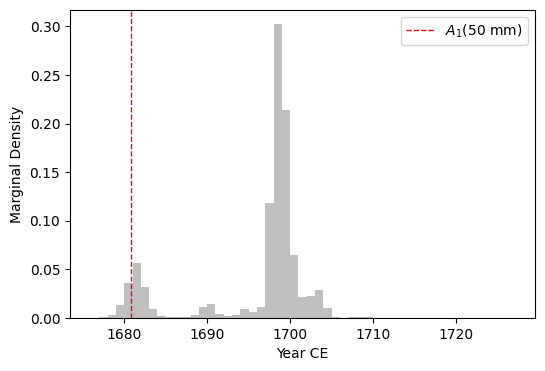

In [22]:
### Jackknife
fig, ax = plt.subplots(figsize=(6, 4))
hists = []
bins = np.arange(bin_range[0], bin_range[1] + dt, dt)
bin_centers = bins[1:] - dt / 2

full_CV_values = np.histogram(data["th"] - data["dc"] * np.sum(short_samples[:, :index], axis = 1), density = True, bins = bins)

for i in range(len(short_samples)):
    CV_values = data["th"] - data["dc"] * np.sum(np.delete(short_samples, i, axis=0)[:, :index], axis = 1)
    hists.append(np.histogram(CV_values, density = True, bins = bins)[0])
    if (i%100 ==0):
        print(i/len(short_samples))


ax.hist(CV_values, bins = bins, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

In [23]:
# print(hists)
n = len(short_samples)
# print(np.shape(full_CV_values[0]))
# print(np.shape(np.array(hists)))
variance  = (n-1) * np.sum((hists - full_CV_values[0][None, :])**2, axis = 0) / n
print(variance)

[0.00000000e+00 3.30198599e-08 1.97642584e-07 8.57392029e-07
 2.39270172e-06 3.64353227e-06 2.10674033e-06 6.17310901e-07
 1.17782181e-07 8.48440194e-08 4.71615024e-08 4.24482700e-08
 1.69477957e-07 7.28335439e-07 9.26320379e-07 2.67952030e-07
 9.89642647e-08 2.25783869e-07 6.12676774e-07 4.17457915e-07
 7.65260622e-07 7.14020997e-06 1.44831946e-05 1.15578120e-05
 4.14976482e-06 1.42733718e-06 1.53560731e-06 1.91161160e-06
 7.05236126e-07 7.07179386e-08 4.71906805e-09 1.88723818e-08
 7.54272806e-08 3.30198599e-08 9.43748770e-09 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 4.71906805e-09]


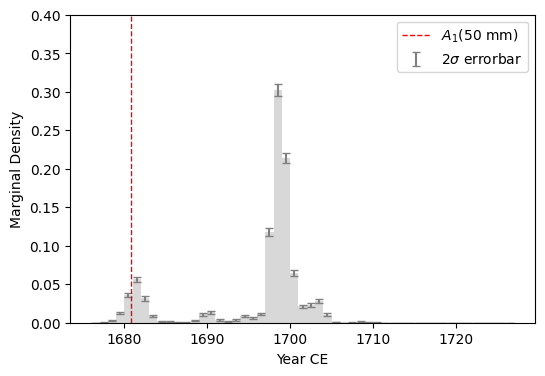

In [24]:
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
fig, ax = plt.subplots(figsize=(6, 4))

# jackknife_array = np.array([n*full_CV_values[0] - (n-1) * hists[i] for i in range(len(hists))])
# print(np.shape(jackknife_array))
# jackknife_est = np.mean(jackknife_array, axis = 0)
# print(jackknife_est - full_CV_values[0])
# print(full_CV_values[0])

# 3. Plot
ax.errorbar(bin_centers, full_CV_values[0], yerr=2*np.sqrt(variance), fmt='none', color = "grey", capsize=3, label = r"2$\sigma$ errorbar")
# lower_bound = full_CV_values[0] - 2 * np.sqrt(variance)
# upper_bound = full_CV_values[0] + 2 * np.sqrt(variance)
# ax.fill_between(bin_centers, lower_bound, upper_bound, 
#                 color="grey", alpha=0.3, label=r"2$\sigma$ uncertainty")
ax.bar(bin_centers, full_CV_values[0], width=np.diff(bins), alpha=0.3, color='gray', align='center')
ax.set_ylim(0, ylim_max)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color=data_color, linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}_error.jpg")


In [25]:
# print(bin_edges)

In [26]:
# energy_values = np.load(f"{output_dir}/energy.npy")[:, cutout:]
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")[:, cutout:]
# true_energies = energy_values + (1 - pt_config["bs"][:, None])*d18o_energy_values


In [27]:
# import matplotlib as mpl
# fig, ax = plt.subplots()

# norm = mpl.colors.Normalize(vmin=min(pt_config['bs']), vmax=max(pt_config['bs']))
# cmap = plt.cm.viridis

# for i in range(pt_config["nt"]):
#     ax.plot(np.linspace(cutout, len(true_energies[i, :] + cutout), len(true_energies[i, :])), true_energies[i, :], color=cmap(norm(pt_config['bs'][i])), alpha = 0.5)
# ax.set_xlabel("Samples")
# ax.set_ylabel("Energy")
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label(r"$\beta_s$")
# ticks = [min(pt_config["bs"]), max(pt_config["bs"])]
# cbar.set_ticks(ticks)
# cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
# cbar.ax.yaxis.set_minor_locator(
#     plt.FixedLocator(pt_config["bs"])
# )
# plt.savefig(f"{output_dir}/energy.jpg")
# plt.show()

In [28]:
# print(true_energies[0])

In [29]:
# fig, ax = plt.subplots(figsize=(6, 4))
# for i in range(pt_config["nt"]):
#     ax.hist(d18o_energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
# # plt.legend()
# plt.savefig(f"{output_dir}/energy_hist.jpg")
# plt.show()   

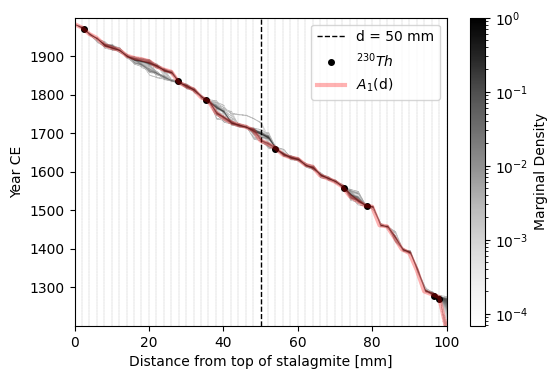

In [30]:
from matplotlib import colors

X = short_samples[:, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(1200, 2000 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = data_color, linewidth=3, alpha = 0.3, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

# del A, C
# gc.collect()


In [31]:
# from matplotlib import colors

# chain = 0
# X = samples[chain, cutout:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'orange', linewidth=3, alpha = 0.2, label = r"$A_2(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean_{chain}_highT.jpg")
# plt.show()


In [32]:
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")